# 작물 종류 추천 및 모델 성능 고도화

In [115]:
import copy
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import kagglehub

from tqdm.auto import tqdm

In [116]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [117]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.random.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [118]:
data_path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset", path="Crop_recommendation.csv")
data_path

'C:\\Users\\playdata2\\.cache\\kagglehub\\datasets\\atharvaingle\\crop-recommendation-dataset\\versions\\1\\Crop_recommendation.csv'

In [119]:
df = pd.read_csv(data_path)
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [120]:
print(df.shape)
print(df.columns)
df.info()

(2200, 8)
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [121]:
df.columns = [
    column.strip().lower()
    for column in df.columns
]

df.columns

Index(['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [122]:
df.isna().sum()

n              0
p              0
k              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [123]:
df.duplicated().sum()

np.int64(0)

In [124]:
df.columns.tolist()

['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

In [125]:
feature_columns = ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']
target_column = 'label'

X = df[feature_columns].copy()
y = df[target_column].copy()

print(X.shape, y.shape)

(2200, 7) (2200,)


In [126]:
class_counts = y.value_counts().sort_index()
print(f'작물 클래스 수: {y.nunique()}')

class_counts.to_frame()

작물 클래스 수: 22


,count
label,
apple,100
banana,100
blackgram,100
chickpea,100
coconut,100
coffee,100
cotton,100
grapes,100
jute,100


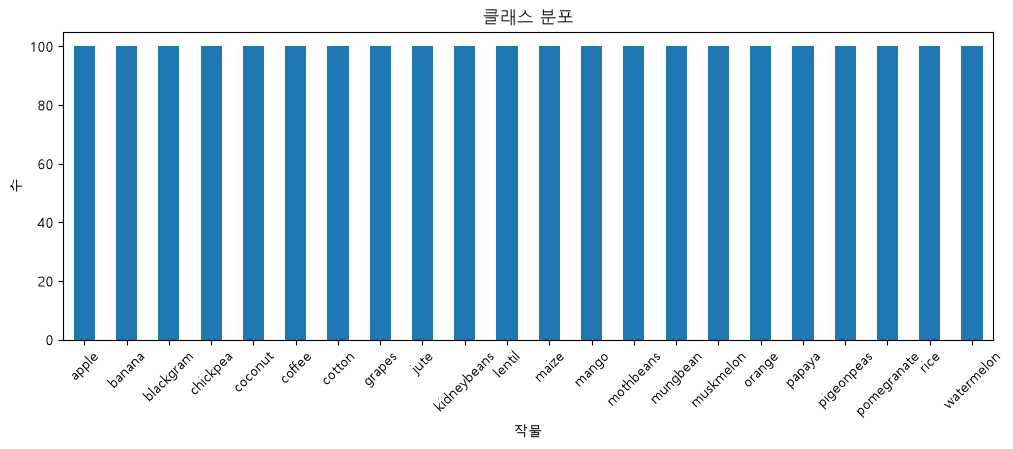

In [127]:
class_counts.plot(kind='bar', figsize=(12, 4))

plt.xlabel('작물')
plt.ylabel('수')
plt.title('클래스 분포')
plt.xticks(rotation=45)
plt.show()

In [128]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = pd.DataFrame({
    'class_index': range(len(label_encoder.classes_)),
    'crop': label_encoder.classes_
})

label_mapping

,class_index,crop
0,0,apple
1,1,banana
2,2,blackgram
3,3,chickpea
4,4,coconut
5,5,coffee
6,6,cotton
7,7,grapes
8,8,jute
9,9,kidneybeans


In [129]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.3,
    stratify=y_encoded,
    random_state=SEED
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=SEED
)

print(X_train.shape, X_valid.shape, X_test.shape)
print(y_train.shape, y_valid.shape, y_test.shape)

(1540, 7) (330, 7) (330, 7)
(1540,) (330,) (330,)


In [130]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print(X_train.mean().round(4))
print(np.round(X_train_scaled.mean(axis=0), 4))
print(X_valid.mean().round(4))
print(np.round(X_valid_scaled.mean(axis=0), 4))
print(X_test.mean().round(4))
print(np.round(X_test_scaled.mean(axis=0), 4))

n               50.4558
p               53.2922
k               48.1286
temperature     25.5831
humidity        71.4399
ph               6.4698
rainfall       103.3550
dtype: float64
[ 0.  0.  0.  0. -0. -0. -0.]
n               50.5545
p               53.0909
k               48.0091
temperature     25.7523
humidity        71.6502
ph               6.4445
rainfall       103.5077
dtype: float64
[ 0.0027 -0.0061 -0.0024  0.033   0.0094 -0.0326  0.0028]
n               50.9970
p               53.9636
k               48.3848
temperature     25.6350
humidity        71.5088
ph               6.4932
rainfall       103.9268
dtype: float64
[0.0146 0.0204 0.0051 0.0101 0.0031 0.0302 0.0104]


In [131]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_valid_tensor.shape, y_valid_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

torch.Size([1540, 7]) torch.Size([1540])
torch.Size([330, 7]) torch.Size([330])
torch.Size([330, 7]) torch.Size([330])


In [132]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_loader))
print(len(valid_loader))
print(len(test_loader))

25
6
6


In [133]:
def evaluate_model(model, data_loader, criterion):
    model.eval()

    total_loss = 0

    all_targets = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_X)
            loss = criterion(logits, batch_y)

            total_loss += (loss.item() * batch_X.size(0))
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(logits, dim=1)

            all_targets.extend(batch_y.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

        average_loss = total_loss / len(data_loader.dataset)
        accuracy = accuracy_score(all_targets, all_predictions)

    return(
        average_loss, accuracy, np.array(all_targets), np.array(all_probabilities), np.array(all_predictions)
    )

In [134]:
def train_model(model, train_loader, valid_loader, criterion, optimizer,
                epochs=100, patience=15, scheduler=None, gradient_clip=None):

    history = {
        'train_loss': [],
        'valid_loss': [],
        'train_accuracy': [],
        'valid_accuracy': [],
        'lr': [],
    }

    best_valid_loss = float('inf')
    best_model_state = None
    patience_count = 0

    for epoch in tqdm(range(1, epochs + 1)):
        model.train()

        total_train_loss = 0.0

        train_targets = []
        train_predictions = []

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)

            loss.backward()
            optimizer.step()

            if gradient_clip is not None:
                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=gradient_clip
                )

            total_train_loss += (loss.item() * batch_X.size(0))
            predictions = torch.argmax(logits, dim=1)

            train_targets.extend(batch_y.cpu().numpy())
            train_predictions.extend(predictions.detach().cpu().numpy())

        train_loss = total_train_loss / len(train_loader.dataset)
        train_accuracy = accuracy_score(train_targets, train_predictions)

        valid_loss, valid_accuracy, _, _, _ = evaluate_model(model, valid_loader, criterion)

        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss),
        history['train_accuracy'].append(train_accuracy),
        history['valid_loss'].append(valid_loss),
        history['valid_accuracy'].append(valid_accuracy),
        history['lr'].append(current_lr)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_model_state = copy.deepcopy(model.state_dict())

            patience_count = 0
        else:
            patience_count += 1

        if scheduler is not None:
            scheduler.step(valid_loss)

        if epoch == 1 or epoch % 10 == 0:
            print(f'Epoch: {epoch:3d} | Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}, Train Acc: {train_accuracy:.3f}, Valid Acc: {valid_accuracy:.3f}, lr: {current_lr}')

        if patience_count >= patience:
            print(f'Ealry Stopping work in Epoch {epoch}')
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return history, best_valid_loss

In [135]:
def count_parameters(model):
    return sum(
        parameter.numel() for parameter in model.parameters()
    )

def calculate_metric(model, data_loader, criterion):
    loss, accuracy, targets, probabilities, predictions = evaluate_model(model, data_loader, criterion)

    metrics = {
        "Loss": loss,
        "Accuracy": accuracy,
        'Macro Precision': precision_score(targets, predictions, average='macro', zero_division=0),
        'Macro Recall': recall_score(targets, predictions, average='macro', zero_division=0),
        'Macro F1-Score': f1_score(targets, predictions, average='macro', zero_division=0),
        'Weighted F1-Score': f1_score(targets, predictions, average='weighted', zero_division=0),
    }

    return metrics, targets, predictions, probabilities

In [136]:
input_size = X_train_tensor.size(1)
num_classes = len(label_encoder.classes_)

print(f'입력 특성 수: {input_size} / 출력 클래스 수: {num_classes}')

입력 특성 수: 7 / 출력 클래스 수: 22


In [137]:
class BaselineMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)            
        )

    def forward(self, x):
        return self.network(x)

baseline_model = BaselineMLP(input_size, num_classes).to(device)
print(baseline_model)
print(f'학습 가능 파라미터 수: {count_parameters(baseline_model)}')

BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=22, bias=True)
  )
)
학습 가능 파라미터 수: 3318


In [138]:
baseline_criterion = nn.CrossEntropyLoss()
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

baseline_history, baseline_best_valid_loss = train_model(baseline_model, train_loader, valid_loader, baseline_criterion, baseline_optimizer, epochs=300, patience=15, scheduler=None, gradient_clip=None)

print(f'기존 모델 최저 검증 손실: {baseline_best_valid_loss:.4f}')

  0%|          | 0/300 [00:00<?, ?it/s]

Epoch:   1 | Train Loss: 3.0077, Valid Loss: 2.8970, Train Acc: 0.129, Valid Acc: 0.264, lr: 0.001
Epoch:  10 | Train Loss: 0.5043, Valid Loss: 0.4643, Train Acc: 0.900, Valid Acc: 0.906, lr: 0.001
Epoch:  20 | Train Loss: 0.1943, Valid Loss: 0.1807, Train Acc: 0.951, Valid Acc: 0.955, lr: 0.001
Epoch:  30 | Train Loss: 0.1143, Valid Loss: 0.1080, Train Acc: 0.971, Valid Acc: 0.982, lr: 0.001
Epoch:  40 | Train Loss: 0.0811, Valid Loss: 0.0762, Train Acc: 0.977, Valid Acc: 0.985, lr: 0.001
Epoch:  50 | Train Loss: 0.0647, Valid Loss: 0.0592, Train Acc: 0.978, Valid Acc: 1.000, lr: 0.001
Epoch:  60 | Train Loss: 0.0534, Valid Loss: 0.0500, Train Acc: 0.984, Valid Acc: 0.994, lr: 0.001
Epoch:  70 | Train Loss: 0.0431, Valid Loss: 0.0421, Train Acc: 0.986, Valid Acc: 0.994, lr: 0.001
Epoch:  80 | Train Loss: 0.0391, Valid Loss: 0.0440, Train Acc: 0.987, Valid Acc: 0.988, lr: 0.001
Epoch:  90 | Train Loss: 0.0466, Valid Loss: 0.0381, Train Acc: 0.982, Valid Acc: 0.985, lr: 0.001
Epoch: 100

In [139]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)            
        )

    def forward(self, x):
        return self.network(x)

improved_model = ImprovedMLP(input_size, num_classes).to(device)
print(improved_model)
print(f'학습 가능 파라미터 수: {count_parameters(improved_model)}')

ImprovedMLP(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=22, bias=True)
  )
)
학습 가능 파라미터 수: 12470


In [140]:
improved_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
improved_optimizer = torch.optim.Adam(improved_model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    improved_optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

improved_history, improved_best_valid_loss = train_model(improved_model, train_loader, valid_loader, improved_criterion, improved_optimizer, epochs=300, patience=15, scheduler=scheduler, gradient_clip=1.0)

print(f'기존 모델 최저 검증 손실: {improved_best_valid_loss:.4f}')

  0%|          | 0/300 [00:00<?, ?it/s]

Epoch:   1 | Train Loss: 2.8929, Valid Loss: 2.6598, Train Acc: 0.204, Valid Acc: 0.421, lr: 0.001
Epoch:  10 | Train Loss: 0.8074, Valid Loss: 0.6372, Train Acc: 0.886, Valid Acc: 0.958, lr: 0.001
Epoch:  20 | Train Loss: 0.6823, Valid Loss: 0.5206, Train Acc: 0.915, Valid Acc: 0.973, lr: 0.001
Epoch:  30 | Train Loss: 0.6412, Valid Loss: 0.4990, Train Acc: 0.938, Valid Acc: 0.982, lr: 0.001
Epoch:  40 | Train Loss: 0.6183, Valid Loss: 0.4794, Train Acc: 0.931, Valid Acc: 0.991, lr: 0.001
Epoch:  50 | Train Loss: 0.6006, Valid Loss: 0.4688, Train Acc: 0.937, Valid Acc: 0.979, lr: 0.001
Epoch:  60 | Train Loss: 0.5746, Valid Loss: 0.4583, Train Acc: 0.953, Valid Acc: 0.988, lr: 0.0005
Epoch:  70 | Train Loss: 0.5637, Valid Loss: 0.4577, Train Acc: 0.951, Valid Acc: 0.988, lr: 0.0005
Epoch:  80 | Train Loss: 0.5531, Valid Loss: 0.4485, Train Acc: 0.959, Valid Acc: 0.988, lr: 0.00025
Epoch:  90 | Train Loss: 0.5600, Valid Loss: 0.4480, Train Acc: 0.949, Valid Acc: 0.991, lr: 0.00025
Epoc

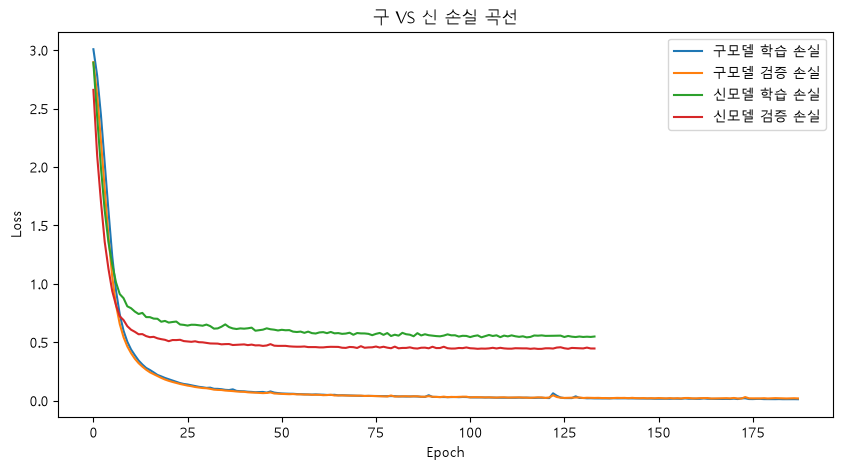

In [141]:
plt.figure(figsize=(10, 5))
plt.plot(baseline_history['train_loss'], label='구모델 학습 손실')
plt.plot(baseline_history['valid_loss'], label='구모델 검증 손실')

plt.plot(improved_history['train_loss'], label='신모델 학습 손실')
plt.plot(improved_history['valid_loss'], label='신모델 검증 손실')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('구 VS 신 손실 곡선')
plt.legend()
plt.show()

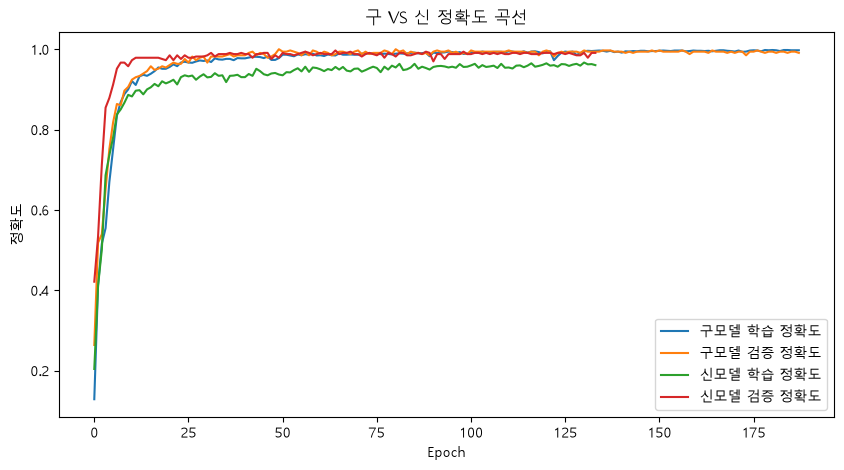

In [142]:
plt.figure(figsize=(10, 5))
plt.plot(baseline_history['train_accuracy'], label='구모델 학습 정확도')
plt.plot(baseline_history['valid_accuracy'], label='구모델 검증 정확도')

plt.plot(improved_history['train_accuracy'], label='신모델 학습 정확도')
plt.plot(improved_history['valid_accuracy'], label='신모델 검증 정확도')

plt.xlabel('Epoch')
plt.ylabel('정확도')
plt.title('구 VS 신 정확도 곡선')
plt.legend()
plt.show()

C:\Users\playdata2\AppData\Local\Temp\ipykernel_31776\3435515792.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


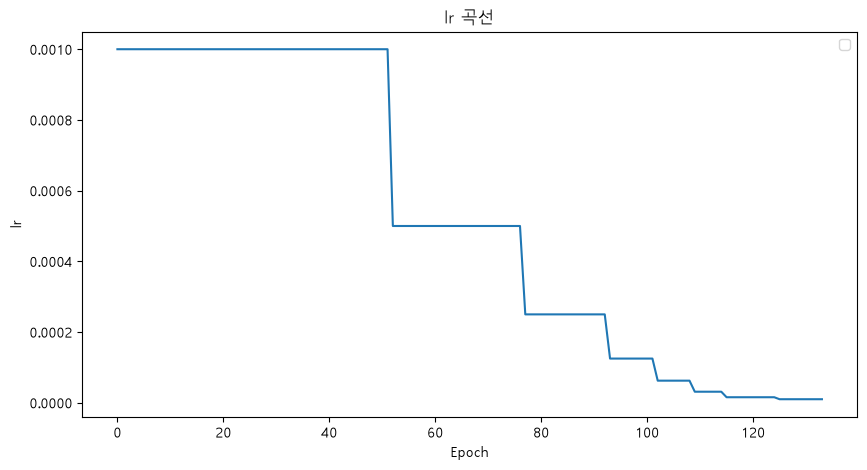

In [143]:
plt.figure(figsize=(10, 5))
plt.plot(improved_history['lr'])

plt.xlabel('Epoch')
plt.ylabel('lr')
plt.title('lr 곡선')
plt.legend()
plt.show()

In [145]:
baseline_metrics, baseline_targets, baseline_predictions, baseline_probability = calculate_metric(
    baseline_model,
    test_loader,
    baseline_criterion
)

improved_metrics, test_targets, test_predictions, test_probability = calculate_metric(
    improved_model,
    test_loader,
    improved_criterion
)

comparison_df = pd.DataFrame({
    'Baseline Model': baseline_metrics,
    'Improved Model': improved_metrics
})

comparison_df

,Baseline Model,Improved Model
Loss,0.020791,0.443343
Accuracy,0.987879,0.987879
Macro Precision,0.988231,0.988971
Macro Recall,0.987879,0.987879
Macro F1-Score,0.987865,0.987845
Weighted F1-Score,0.987865,0.987845


In [150]:
report = classification_report(
    test_targets, test_predictions,
    labels=range(num_classes),
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df.round(4)

,precision,recall,f1-score,support
apple,1.0000,1.0000,1.0000,15.0000
banana,1.0000,1.0000,1.0000,15.0000
blackgram,1.0000,0.9333,0.9655,15.0000
chickpea,1.0000,1.0000,1.0000,15.0000
coconut,1.0000,1.0000,1.0000,15.0000
coffee,1.0000,1.0000,1.0000,15.0000
cotton,1.0000,1.0000,1.0000,15.0000
grapes,1.0000,1.0000,1.0000,15.0000
jute,0.8824,1.0000,0.9375,15.0000
kidneybeans,1.0000,1.0000,1.0000,15.0000


In [151]:
torch.save(
    {
        'model_state_dict': improved_model.state_dict(),
        'input_size': input_size,
        'num_classes': num_classes,
        'feature_columns': feature_columns,
        'class_name': label_encoder.classes_.tolist()
    },
    'crop_improved_model.pth'
)

joblib.dump(scaler, 'crop_scaler.pkl')
joblib.dump(label_encoder, 'crop_label_encoder.pkl')
print('Done')

Done


In [152]:
df.columns

Index(['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [ ]:
def recommend_crop(n, p, k, temperature, humidity, ph, rainfall, top_k=3):
    sample = pd.DataFrame(
        [[n, p, k, temperature, humidity, ph, rainfall]],
        columns=feature_columns
    )

    sample_scaled = scaler.transform(sample)
    sample_tensor = torch.FloatTensor(sample_scaled).to(device)

    improved_model.eval()
    with torch.no_grad():
        logits = improved_model(sample_tensor)

        probabilities = torch.softmax(logits, dim=1)[0]

    top_probabilities, top_indices = torch.topk(probabilities, k=top_k)

    crops = label_encoder.inverse_transform(top_indices.cpu().numpy())

    result = pd.DataFrame({
        'crop': crops,
        'probability': (top_probabilities.cpu().numpy() * 100).round(2)
    })

    return result